In [1]:
import os

import imageio
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import datasets
from torchvision import transforms
import torch.nn.functional as F



%matplotlib inline

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [2]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=False)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [7]:
class VariationalEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)
        self.linear3 = nn.Linear(512, latent_dims)

        self.N = torch.distributions.Normal(0, 1)  # Оставляем распределение на CPU
        self.kl = 0  # Инициализируем KL дивергенцию

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu = self.linear2(x)
        sigma = torch.exp(self.linear3(x))
        z = mu + sigma * self.N.sample(mu.shape)  # Сэмплируем на том же устройстве, что и mu
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1/2).sum()
        return z

In [8]:
class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))
        return z.reshape((-1, 1, 28, 28))

In [9]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        <определите архитектуры encoder и decoder
        помните, у encoder должны быть два "хвоста",
        т.е. encoder должен кодировать картинку в 2 переменные -- mu и logsigma>

    def encode(self, x):
        <реализуйте forward проход энкодера
        в качестве ваозвращаемых переменных -- mu и logsigma>

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):a
        if self.training:
            <засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma>
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z):
        <реализуйте forward проход декодера
        в качестве возвращаемой переменной -- reconstruction>

        return reconstruction

    def forward(self, x):
        <используя encode и decode, реализуйте forward проход автоэнкодера
        в качестве ваозвращаемых переменных -- mu, logsigma и reconstruction>
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [ ]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = <напишите код для KL-дивергенции, пользуясь формулой выше>
    return

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = <binary cross-entropy>
    return loss(reconstruction, x)

def loss_vae(x, mu, logsigma, reconstruction):
    return <соедините тут две компоненты лосса. Mind the sign!>

И обучим модель:

In [ ]:
criterion = loss_vae

autoencoder = VAE()

optimizer = <Ваш любимый оптимизатор>

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [11]:
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())
    autoencoder.train()  # Переводим модель в режим обучения

    for epoch in range(epochs):
        epoch_loss = 0.0  # Для накопления loss за эпоху
        num_batches = 0   # Счётчик батчей

        for x, y in data:
            x = x.to(device)  # GPU
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat)**2).sum()  + autoencoder.encoder.kl # MSE loss
            loss.backward()
            opt.step()

            epoch_loss += loss.item()  # Накопление loss
            num_batches += 1

        # Выводим средний loss за эпоху
        avg_loss = epoch_loss / num_batches
        print(f'Epoch: {epoch}, Loss: {avg_loss:.4f}')

    return autoencoder

In [12]:
latent_dims = 2

In [13]:
vae = VariationalAutoencoder(latent_dims).to(device) # GPU
vae = train(vae, train_loader)

Epoch: 0, Loss: 1432.8121
Epoch: 1, Loss: 1332.2174
Epoch: 2, Loss: 1303.4748
Epoch: 3, Loss: 1285.2049
Epoch: 4, Loss: 1271.5059
Epoch: 5, Loss: 1260.3145
Epoch: 6, Loss: 1251.8201
Epoch: 7, Loss: 1245.3517
Epoch: 8, Loss: 1238.5104
Epoch: 9, Loss: 1232.7947
Epoch: 10, Loss: 1228.4932
Epoch: 11, Loss: 1224.5990
Epoch: 12, Loss: 1220.4121
Epoch: 13, Loss: 1217.0061
Epoch: 14, Loss: 1213.4526
Epoch: 15, Loss: 1211.3720
Epoch: 16, Loss: 1208.5675
Epoch: 17, Loss: 1205.9446
Epoch: 18, Loss: 1203.4093
Epoch: 19, Loss: 1201.4429


Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

In [ ]:
< тут Ваш код: выведите первые Х картинок и их реконструкций из val выборки на экран>

In [14]:
def plot_reconstructed(autoencoder, r0=(-5, 10), r1=(-10, 5), n=12):
    w = 28
    img = np.zeros((n*w, n*w))
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y]]).to(device)
            x_hat = autoencoder.decoder(z)
            x_hat = x_hat.reshape(28, 28).to('cpu').detach().numpy()
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat
    plt.imshow(img, extent=[*r0, *r1])

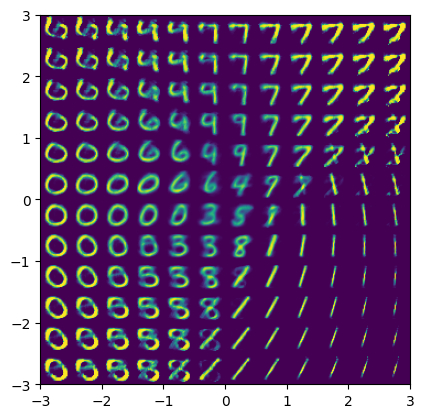

In [17]:
plot_reconstructed(vae, r0=(-3, 3), r1=(-3, 3))

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [39]:
def generate_images(model, n_samples=16, latent_dim=2, device='cpu'):
    """
    Generate images by sampling from the latent space of the VAE.
    
    Args:
        model: trained VAE model
        n_samples: number of samples to generate (will create a grid of sqrt(n_samples) x sqrt(n_samples))
        latent_dim: dimension of the latent space
        device: device to run the model on
    
    Returns:
        Generated images as a tensor
    """
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        # Sample from standard normal distribution
        z = torch.randn(n_samples, latent_dim).to(device)
        
        # Generate images using the decoder
        generated_images = model.decoder(z)
        
        # Convert to numpy for visualization
        generated_images = generated_images.cpu().numpy()
        
        # Create a grid of images
        grid_size = int(np.sqrt(n_samples))
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(5, 5))
        
        for i in range(grid_size):
            for j in range(grid_size):
                idx = i * grid_size + j
                if idx < n_samples:
                    axes[i, j].imshow(generated_images[idx].squeeze(), cmap='gray')
                    axes[i, j].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return z    



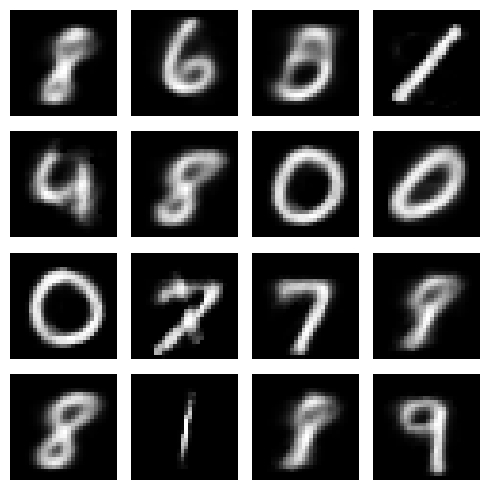

In [40]:
dots=generate_images(vae, n_samples=16, latent_dim=2, device=device)

Интерполяция

In [18]:
def interpolate(autoencoder, x_1, x_2, n=12):
    z_1 = autoencoder.encoder(x_1)
    z_2 = autoencoder.encoder(x_2)
    z = torch.stack([z_1 + (z_2 - z_1)*t for t in np.linspace(0, 1, n)])
    interpolate_list = autoencoder.decoder(z)
    interpolate_list = interpolate_list.to('cpu').detach().numpy()

    w = 28
    img = np.zeros((w, n*w))
    for i, x_hat in enumerate(interpolate_list):
        img[:, i*w:(i+1)*w] = x_hat.reshape(28, 28)
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])

In [23]:
# x, y = data.__iter__().next() # hack to grab a batch
x, y = next(iter(train_loader))
x_1 = x[y == 1][1].to(device) # find a 1
x_2 = x[y == 0][1].to(device) # find a 0

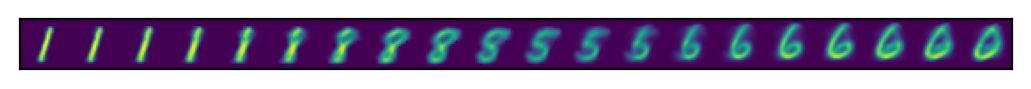

In [ ]:
interpolate(vae, x_1, x_2, n=20)

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [43]:
def plot_latent(autoencoder, data, num_batches=100):
    for i, (x, y) in enumerate(data):
        z = autoencoder.encoder(x.to(device))
        z = z.to('cpu').detach().numpy()
        plt.scatter(z[:, 0], z[:, 1], c=y, cmap='tab10')
        if i > num_batches:
            plt.colorbar()
            break
    for i, (x,y) in enumerate(dots):
        plt.scatter(x, y, c='blue',  marker='x')
        plt.annotate(f'{i}', (x, y), xytext=(5, 5),    textcoords='offset points')


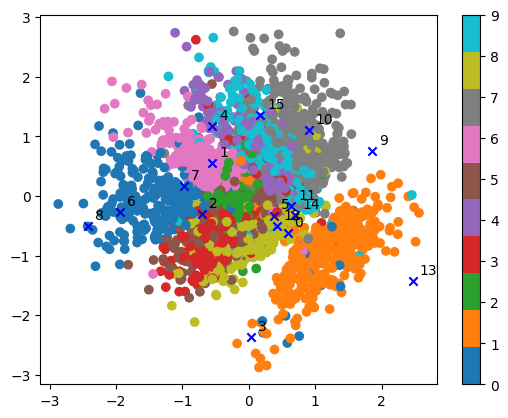

In [44]:
plot_latent(vae, train_loader)

Что вы думаете о виде латентного представления?

__Congrats v2.0!__